In [16]:
import csv
import os
import re
import matplotlib.pyplot as plt
from datetime import datetime

In [17]:
def recordObservation():
    file_exists = os.path.isfile("weather_data.csv")
    file_empty = os.path.getsize("weather_data.csv") == 0 if file_exists else True

    #read existing dates
    existing_dates = set()
    if file_exists and not file_empty:
        with open("weather_data.csv", "r") as file:
            reader = csv.reader(file)
            next(reader)
            for row in reader:
                existing_dates.add(row[0])

    #date
    while True:
        date = input("Enter date (MM-DD-YYYY): ")
        
        try:
            date_obj = datetime.strptime(date, "%m-%d-%Y")
            min_date = datetime(2025, 1, 1)
            today = datetime.today()
            
            if date_obj < min_date:
                print("**Date must be from 2025 onwards**")
            elif date_obj > today:
                print("**Date cannot be in the future**")
            elif date in existing_dates:
                print("**This date already exists**")
            else:
                break
                
        except:
            print("**Invalid format.. use MM-DD-YYYY**")

    #temp
    while True:
        temp = input("Enter temperature (C): ")
        try:
            temp_value = float(temp)
            if temp_value < -50 or temp_value > 60:
                print("**temperature must not exceed two digits**")
                continue
            break
        except:
            print("**Temperature must be a number**")

    #condition
    while True:
        cond = input("Enter condition (Sunny, Cloudy, Rainy or Windy): ")
        
        valid_conditions = ["sunny", "cloudy", "rainy", "windy"]
        if cond.lower() in valid_conditions:
            cond = cond.capitalize()
            break
        print("**Condition must be a word (e.g., sunny, rainy)**")

    #humidity
    while True:
        humidity = input("Enter humidity (%): ")
        if humidity.isdigit():
            h_value = int(humidity)
            if 0 <= h_value <= 100:
                break
            else:
                print("**Humidity must be between 0 and 100**")
        else:
            print("**Humidity must be a whole number**")

    #wind speed
    while True:
        wind_speed = input("Enter wind speed (km/h): ")
        try:
            w_value = float(wind_speed)
            if w_value < 0:
                print("**Wind speed cannot be negative**")
            elif w_value > 200:
                print("**Wind speed is unrealistically high**")
            else:
                break
        except:
            print("**Wind speed must be a number**")

    new_row = [date, temp_value, cond, h_value, w_value]

    with open("weather_data.csv", mode="a", newline="") as file:
        writer = csv.writer(file)

        if not file_exists or file_empty:
            writer.writerow(["Date", "Temperature", "Condition", "Humidity", "Wind Speed"])

        writer.writerow(new_row)

    print("-Your observation is recorded-")

In [18]:
recordObservation()

Enter date (MM-DD-YYYY):  04-04-2024


**Date must be from 2025 onwards**


Enter date (MM-DD-YYYY):  04-04-2025
Enter temperature (C):  30
Enter condition (Sunny, Cloudy, Rainy or Windy):  cloudy
Enter humidity (%):  40
Enter wind speed (km/h):  20


-Your observation is recorded-


In [19]:
def search():
    search_date = input("Enter the date (MM-DD-YYYY): ")
    
    if not re.match(r"\d\d-\d\d-\d\d\d\d", search_date):
        print("**Invalid date format .. enter MM-DD-YYYY**")
        return

    if not os.path.isfile("weather_data.csv"):
        print("data file not found")
        return

    date_found = False

    with open("weather_data.csv", mode="r") as file:
        reader = csv.reader(file)
        header = next(reader)

        for row in reader:
            if row[0] == search_date:
                if not date_found:
                    print("\nResults:\n")
                    print(", ".join(header))
                print(", ".join(row))
                date_found = True

    if not date_found:
        print("**There are no observations for this date**")

In [20]:
search()

Enter the date (MM-DD-YYYY):  04-04-2025



Results:

Date, Temperature, Condition, Humidity, Wind Speed
04-04-2025, 30.0, Cloudy, 40, 20.0


In [21]:
def displayTrends():
    if not os.path.isfile("weather_data.csv"):
        print("No data available")
        return

    records = []

    with open("weather_data.csv", mode="r") as file:
        reader = csv.reader(file)
        next(reader)

        for row in reader:
            try:
                date_obj = datetime.strptime(row[0], "%m-%d-%Y")
                temp = float(row[1])
                records.append((date_obj, temp))
            except:
                continue

    records.sort(key=lambda x: x[0])

    dates = [r[0].strftime("%m-%d-%Y") for r in records]
    temps = [r[1] for r in records]

    plt.figure()
    plt.plot(dates, temps, marker='o')

    plt.title("Temperature Trends")
    plt.xlabel("Date")
    plt.ylabel("Temperature (°C)")

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

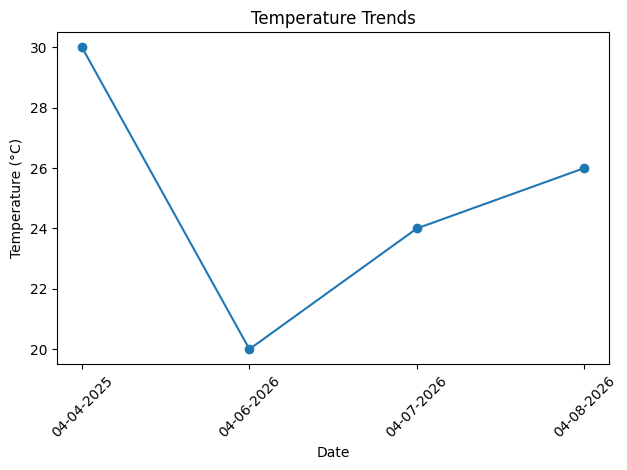

In [22]:
displayTrends()